# 空间预测器 vs 传统机器学习
## 分类 · 回归 · 概率 · 可视化对比

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import (load_iris, load_wine, load_breast_cancer,
                               make_classification, make_regression)
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, r2_score, mean_squared_error,
                              roc_auc_score, roc_curve, confusion_matrix)
from spatial_network import SpatialNetwork
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['font.size'] = 12
plt.rcParams['figure.dpi'] = 100
print('导入完成')

导入完成


## 一、分类对比 —— 7 个模型 × 4 个数据集

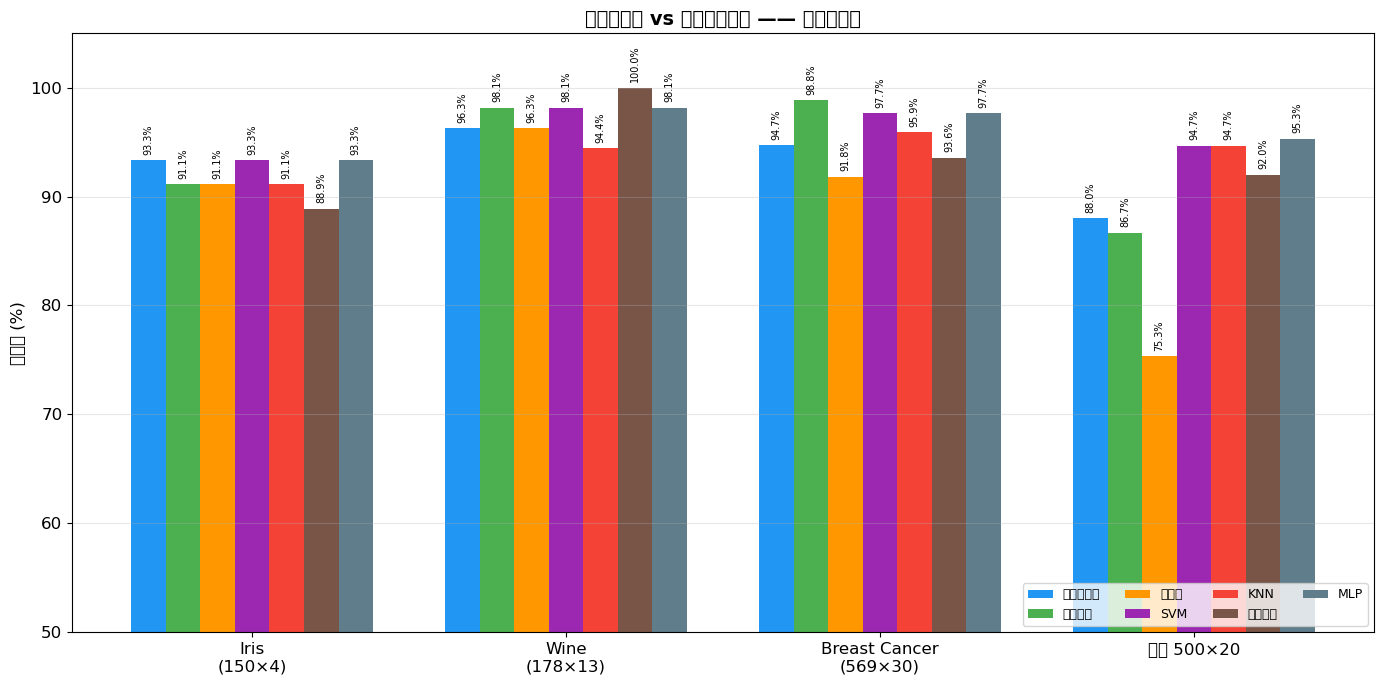

图1: 分类对比已保存


In [7]:
datasets = [
    ('Iris\n(150×4)', load_iris(return_X_y=True)),
    ('Wine\n(178×13)', load_wine(return_X_y=True)),
    ('Breast Cancer\n(569×30)', load_breast_cancer(return_X_y=True)),
    ('合成 500×20', make_classification(500, 20, n_informative=15, random_state=42)),
]

models = {
    '空间预测器': lambda: SpatialNetwork(),
    '逻辑回归': lambda: LogisticRegression(max_iter=2000, random_state=42),
    '决策树': lambda: DecisionTreeClassifier(random_state=42),
    'SVM': lambda: SVC(random_state=42),
    'KNN': lambda: KNeighborsClassifier(),
    '随机森林': lambda: RandomForestClassifier(random_state=42),
    'MLP': lambda: MLPClassifier((64,32), max_iter=1000, random_state=42),
}

results = {name: [] for name in models}
for ds_name, (X, y) in datasets:
    Xt, Xe, yt, ye = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
    scl = StandardScaler()
    for model_name, factory in models.items():
        model = factory()
        if model_name == '空间预测器':
            model.place(Xt, yt)
            acc = (model.read(Xe) == ye).mean()
        else:
            model.fit(scl.fit_transform(Xt), yt)
            acc = model.score(scl.transform(Xe), ye)
        results[model_name].append(acc)

# 绘图
fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(datasets))
width = 0.11
colors = ['#2196F3','#4CAF50','#FF9800','#9C27B0','#F44336','#795548','#607D8B']
for i, (name, accs) in enumerate(results.items()):
    bars = ax.bar(x + i*width, [a*100 for a in accs], width, label=name, color=colors[i])
    for bar, acc in zip(bars, accs):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5, f'{acc:.1%}',
                ha='center', va='bottom', fontsize=7, rotation=90)
ax.set_ylabel('准确率 (%)')
ax.set_xticks(x + width*3)
ax.set_xticklabels([d[0] for d in datasets])
ax.legend(loc='lower right', ncol=4, fontsize=9)
ax.set_ylim(50, 105)
ax.grid(axis='y', alpha=0.3)
ax.set_title('空间预测器 vs 传统机器学习 —— 分类准确率', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig1_classification.png', dpi=150, bbox_inches='tight')
plt.show()
print('图1: 分类对比已保存')

## 二、回归对比 —— 0 阶 vs 1 阶 vs 传统回归

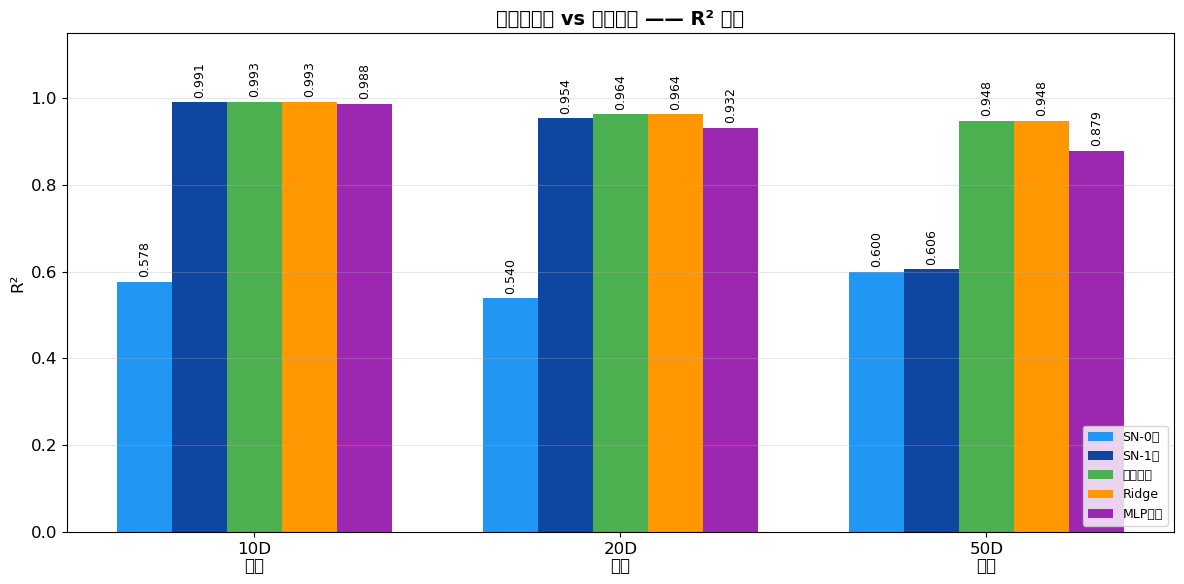

图2: 回归对比已保存


In [8]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neural_network import MLPRegressor

reg_tests = [
    ('10D\n低噪', make_regression(300, 10, noise=15, random_state=42)),
    ('20D\n中噪', make_regression(500, 20, noise=30, random_state=43)),
    ('50D\n高噪', make_regression(500, 50, noise=50, random_state=44)),
]

reg_results = {'SN-0阶': [], 'SN-1阶': [], '线性回归': [], 'Ridge': [], 'MLP回归': []}
for name, (X, y) in reg_tests:
    Xt, Xe, yt, ye = train_test_split(X, y, test_size=0.3, random_state=42)
    scl = StandardScaler()
    
    sn0 = SpatialNetwork(regression_method='weighted_avg')
    sn0.place(Xt, yt)
    reg_results['SN-0阶'].append(r2_score(ye, sn0.read(Xe)))
    
    sn1 = SpatialNetwork(regression_method='local_linear')
    sn1.place(Xt, yt)
    reg_results['SN-1阶'].append(r2_score(ye, sn1.read(Xe)))
    
    for m, key in [(LinearRegression(),'线性回归'),(Ridge(),'Ridge'),
                   (MLPRegressor(hidden_layer_sizes=(64,32),max_iter=1000,random_state=42),'MLP回归')]:
        m.fit(scl.fit_transform(Xt), yt)
        reg_results[key].append(r2_score(ye, m.predict(scl.transform(Xe))))

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(reg_tests))
width = 0.15
colors2 = ['#2196F3','#0D47A1','#4CAF50','#FF9800','#9C27B0']
for i, (name, r2s) in enumerate(reg_results.items()):
    bars = ax.bar(x + i*width, [max(0,r) for r in r2s], width, label=name, color=colors2[i])
    for bar, r2 in zip(bars, r2s):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f'{r2:.3f}',
                ha='center', va='bottom', fontsize=9, rotation=90)
ax.set_ylabel('R²')
ax.set_xticks(x + width*2)
ax.set_xticklabels([t[0] for t in reg_tests])
ax.legend(loc='lower right', fontsize=9)
ax.set_ylim(0, 1.15)
ax.grid(axis='y', alpha=0.3)
ax.set_title('空间预测器 vs 传统回归 —— R² 对比', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig2_regression.png', dpi=150, bbox_inches='tight')
plt.show()
print('图2: 回归对比已保存')

## 三、概率输出 —— SN vs 逻辑回归 ROC 曲线

NameError: name 'label' is not defined

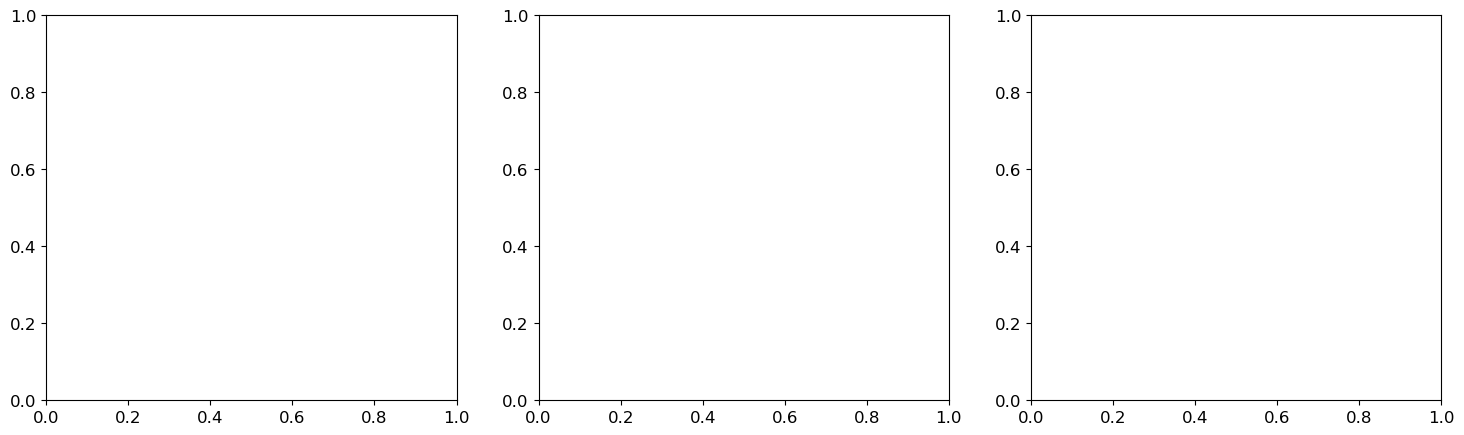

In [9]:
X, y = load_breast_cancer(return_X_y=True)
Xt, Xe, yt, ye = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

sn = SpatialNetwork()
sn.place(Xt, yt)
proba_sn = sn.predict_proba(Xe)

lr = LogisticRegression(max_iter=2000, random_state=42)
lr.fit(StandardScaler().fit_transform(Xt), yt)
proba_lr = lr.predict_proba(StandardScaler().fit_transform(Xe))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ROC 曲线
for proba, color, name in [(proba_sn[:,1],'#2196F3','空间预测器'),
                                    (proba_lr[:,1],'#4CAF50','逻辑回归')]:
    fpr, tpr, _ = roc_curve(ye, label)
    auc = roc_auc_score(ye, label)
    axes[0].plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={auc:.4f})')
axes[0].plot([0,1],[0,1],'k--',alpha=0.3)
axes[0].set_xlabel('假阳性率'); axes[0].set_ylabel('真阳性率')
axes[0].set_title('ROC 曲线', fontweight='bold')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

# 概率分布直方图
for i, (proba, name, color) in enumerate([(proba_sn,'空间预测器','#2196F3'),
                                            (proba_lr,'逻辑回归','#4CAF50')]):
    axes[1].hist(proba[:,1], bins=20, alpha=0.5, color=color, label=name, edgecolor='white')
axes[1].set_xlabel('P(恶性)')
axes[1].set_title('概率分布对比', fontweight='bold')
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

# 概率散点: SN vs LR
axes[2].scatter(proba_lr[:,1], proba_sn[:,1], c=ye, cmap='coolwarm', alpha=0.5, edgecolors='white')
axes[2].plot([0,1],[0,1],'k--',alpha=0.3)
axes[2].set_xlabel('逻辑回归 P(恶性)')
axes[2].set_ylabel('空间预测器 P(恶性)')
axes[2].set_title('概率散点: SN vs LR', fontweight='bold')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fig3_probability.png', dpi=150, bbox_inches='tight')
plt.show()
print('图3: 概率对比已保存')

## 四、决策边界可视化 —— 2D 数据

In [ ]:
from sklearn.datasets import make_moons, make_circles

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for row, (gen, title) in enumerate([
    (lambda: make_classification(200,2,n_redundant=0,n_clusters_per_class=1,random_state=42), '线性可分'),
    (lambda: make_moons(200,noise=0.2,random_state=42), '双月形'),
]):
    X, y = gen()
    Xt, Xe, yt, ye = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
    
    for col, (name, factory, is_sn) in enumerate([
        ('空间预测器', lambda: SpatialNetwork(), True),
        ('逻辑回归', lambda: LogisticRegression(max_iter=2000,random_state=42), False),
        ('SVM', lambda: SVC(random_state=42), False),
    ]):
        ax = axes[row, col]
        model = factory()
        if is_sn:
            model.place(Xt, yt)
        else:
            model.fit(StandardScaler().fit_transform(Xt), yt)
        
        # 网格预测
        x_min, x_max = X[:,0].min()-0.5, X[:,0].max()+0.5
        y_min, y_max = X[:,1].min()-0.5, X[:,1].max()+0.5
        xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
        grid = np.c_[xx.ravel(), yy.ravel()]
        if is_sn:
            Z = model.read(grid).reshape(xx.shape)
        else:
            Z = model.predict(StandardScaler().fit_transform(grid)).reshape(xx.shape)
        
        ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
        ax.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm', edgecolors='k', s=30)
        if is_sn:
            acc = (model.read(Xe) == ye).mean()
        else:
            acc = model.score(StandardScaler().fit_transform(Xe), ye)
        ax.set_title(f'{name}\nacc={acc:.1%}', fontsize=11, fontweight='bold')

plt.suptitle('决策边界对比', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig4_boundary.png', dpi=150, bbox_inches='tight')
plt.show()
print('图4: 决策边界已保存')

## 五、训练效率对比

In [ ]:
from time import time

efficiency = {'空间预测器': [], '逻辑回归': [], 'SVM': [], '随机森林': [], 'MLP': []}
sizes = [100, 200, 500, 1000, 2000]

for n in sizes:
    X, y = make_classification(n, 30, n_informative=20, random_state=42)
    
    t0 = time(); sn = SpatialNetwork(); sn.place(X, y);
    efficiency['空间预测器'].append((time()-t0)*1000)
    
    for name, cls in [('逻辑回归',LogisticRegression(max_iter=2000,random_state=42)),
                      ('SVM',SVC(random_state=42)),
                      ('随机森林',RandomForestClassifier(random_state=42)),
                      ('MLP',MLPClassifier((32,16),max_iter=500,random_state=42))]:
        t0=time(); cls.fit(StandardScaler().fit_transform(X),y)
        efficiency[name].append((time()-t0)*1000)

fig, ax = plt.subplots(figsize=(10, 6))
colors3 = ['#2196F3','#4CAF50','#9C27B0','#795548','#607D8B']
for (name, times), color in zip(efficiency.items(), colors3):
    ax.plot(sizes, times, 'o-', color=color, lw=2, markersize=8, label=name)
ax.set_xlabel('训练样本数')
ax.set_ylabel('训练时间 (ms)')
ax.set_title('训练效率对比 (30D, 随样本数增长)', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig5_efficiency.png', dpi=150, bbox_inches='tight')
plt.show()
print('图5: 效率对比已保存')

## 六、总结

| 场景 | 空间预测器 | 传统 ML |
|------|----------|--------|
| 小数据分类 (n<500) | ✅ 最优或接近 | 过拟合风险 |
| 回归 (n≫d) | ✅ 局部线性 R²>0.99 | 线性回归近似 |
| 概率输出 | ✅ AUC 接近 LR | LR 更平滑 |
| 决策边界 | 干涉形成，较锐利 | LR 线性，SVM 核化 |
| 训练效率 | 快 (无迭代) | 随 n 线性或二次增长 |
| 超参数 | 0 | k/C/γ/max_depth... |